In [15]:
from langgraph.graph import StateGraph, START, END
from groq import Groq
from typing import TypedDict, Annotated
from langgraph.graph import add_messages
import time
import operator
from groq import Groq
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage


In [16]:
load_dotenv()
api_key1 = os.getenv("API_KEY")
api_key2 = os.getenv("API_KEY2")

llm = "llama-3.3-70b-versatile"

# ---------- MODELS ----------
model_used1 = ChatGroq(api_key=api_key1, model=llm, temperature=0.2)
model_used2 = ChatGroq(api_key=api_key2, model=llm, temperature=0.2)

In [17]:
class LLMState(TypedDict):
    question:str
    elaborated_question:str
    contratdictory_question:str
    response:str

In [18]:
def elaborator(state: LLMState):
    response = model_used1.invoke(
        [HumanMessage(content=f"Make this prompt better:\n{state['question']}")]
    )
    return {"elaborated_question": response.content}


In [19]:
def contradictor(state: LLMState):
    response = model_used2.invoke(
        [HumanMessage(content=f"Create a contradictory question for this:\n{state['question']}")]
    )
    return {"contratdictory_question": response.content}


In [20]:
def asker(state: LLMState):
    time.sleep(5)
    response = model_used2.invoke(
        [HumanMessage(content=f"""
Using the question:
{state['elaborated_question']}

And also satisfying:
{state['contratdictory_question']}

Give a proper answer.
""")]
    )
    return {"response": response.content}


In [21]:
graph = StateGraph(LLMState)

graph.add_node("elaborator",elaborator)
graph.add_node("contradictor",contradictor)
graph.add_node("asker",asker)

graph.add_edge(START,"elaborator")
graph.add_edge(START,"contradictor")
graph.add_edge("elaborator","asker")
graph.add_edge("contradictor","asker")
graph.add_edge("asker",END)

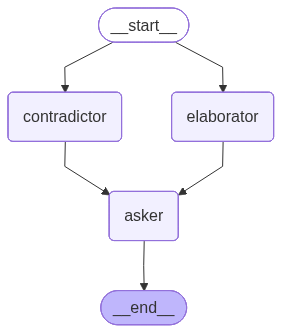

In [22]:
graph.compile()

In [23]:
app = graph.compile()

In [24]:
initial_state={
    'question':"Why should we study?"
}
app.invoke(initial_state)

{'question': 'Why should we study?',
 'elaborated_question': 'Here are a few revised versions of the prompt:\n\n1. What are the benefits of studying, and how can it impact our personal and professional lives?\n2. Why is education important, and what role does studying play in achieving our goals and realizing our potential?\n3. What are the short-term and long-term advantages of dedicating time and effort to studying, and how can it shape our futures?\n4. How can studying enrich our lives, broaden our perspectives, and prepare us for success in an increasingly complex and competitive world?\n5. What are the most compelling reasons to prioritize studying, and how can it lead to personal growth, intellectual development, and a more fulfilling life?\n\nThese revised prompts encourage more thoughtful and nuanced discussions about the importance of studying, and can help to elicit more detailed and insightful responses.',
 'contratdictory_question': 'Why is it pointless to study when we can